# Tarea N°1 — Inteligencia Artificial 2026-1
Universidad Diego Portales — Facultad de Ingeniería y Ciencias

**Estudiante:** Alonso Iturra

**Declaración de uso de herramientas generativas:** Se utilizo Gemini para argumentar y entender conceptos.

## Segunda parte: Modelo Oculto de Markov (HMM)

Para esta sección se empleará el dataset de **Human Activity Recognition Using Smartphones**. El cual es un dataset en el cual participaron 30 sujetos, consiste en que cada sujeto con su telefono realiza una de seis actividades (Caminar, subir escaleras, bajar escaleras, sentarse, estar de pie, acostado).

### Dataset
- **Fuente:** [UCI — Human Activity Recognition](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)

## 2.1 Definición formal de estados y observaciones

### Estados ocultos (6)
Cada estado corresponde a una actividad humana:

| Estado | ID | Actividad |
|--------|-----|-----------|
| $S_1$ | 0 | Caminar (Walking) |
| $S_2$ | 1 | Subir escaleras (Walking Upstairs) |
| $S_3$ | 2 | Bajar escaleras (Walking Downstairs) |
| $S_4$ | 3 | Sentado (Sitting) |
| $S_5$ | 4 | De pie (Standing) |
| $S_6$ | 5 | Acostado (Laying) |

### Observaciones (9)
Se seleccionan 2 índices del dataset de sensores, cada uno discretizado en 3 niveles (bajo, medio, alto), generando $3 \times 3 = 9$ observaciones posibles.

**Índices seleccionados:**
1. **Índice de aceleración:** promedio de columnas 200-201 (tBodyAccMag-mean y tBodyAccMag-std)
2. **Índice de giroscopio:** promedio de columnas 239-240 (tBodyGyroMag-mean y tBodyGyroMag-std)

**Criterio de discretización:** Se usa `pd.qcut` con 3 quantiles (terciles), lo que divide los datos en 3 grupos de igual tamaño aproximado (percentiles 33 y 66). Esto es robusto porque no depende de la escala de los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm

np.random.seed(42)
sns.set_style('whitegrid')

# Cargamos los datos de entrenamiento
path = 'UCI HAR Dataset/train/'
X_train = pd.read_csv(path + 'X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv(path + 'y_train.txt', header=None)
subject_train = pd.read_csv(path + 'subject_train.txt', header=None)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Sujetos: {subject_train[0].nunique()}")

# Mapa de actividades
activity_map = {0: 'Caminar', 1: 'Subir', 2: 'Bajar', 3: 'Sentado', 4: 'De pie', 5: 'Acostado'}

X_train: (7352, 561)
y_train: (7352, 1)
Sujetos: 21


In [2]:
# Discretización de los índices
def discretizar(col):
    return pd.qcut(col, q=3, labels=[0, 1, 2])

# Índice de aceleración: promedio cols 200-201
Iacc = (X_train.iloc[:, 200] + X_train.iloc[:, 201]) / 2
# Índice de giroscopio: promedio cols 239-240
Igyro = (X_train.iloc[:, 239] + X_train.iloc[:, 240]) / 2

# Discretizar en 3 niveles: bajo(0), medio(1), alto(2)
Iacc_disc = discretizar(Iacc).astype(int)
Igyro_disc = discretizar(Igyro).astype(int)

# Crear observaciones combinadas: obs = 3 * nivel_acc + nivel_gyro -> 9 símbolos (0-8)
observaciones = Iacc_disc * 3 + Igyro_disc

print("Distribución de la discretización:")
print(f"  Aceleración: {Iacc_disc.value_counts().sort_index().to_dict()}")
print(f"  Giroscopio:  {Igyro_disc.value_counts().sort_index().to_dict()}")
print(f"\nObservaciones posibles: {sorted(observaciones.unique())}")
print(f"Distribución de observaciones:")
print(observaciones.value_counts().sort_index())

Distribución de la discretización:
  Aceleración: {0: 2451, 1: 2450, 2: 2451}
  Giroscopio:  {0: 2451, 1: 2450, 2: 2451}

Observaciones posibles: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8)]
Distribución de observaciones:
0    2210
1     241
3     241
4    1884
5     325
7     325
8    2126
Name: count, dtype: int64


## 2.2 Estimación manual de parámetros

Se construyen secuencias por sujeto y se estiman manualmente:
- **Vector inicial $\pi$:** frecuencia relativa de la primera actividad de cada sujeto
- **Matriz de transición $A$:** frecuencia de transiciones entre actividades consecutivas
- **Matriz de emisión $B$:** frecuencia de cada observación dado cada estado

In [3]:
# Construir secuencias por sujeto
data = pd.DataFrame({
    'subject': subject_train[0],
    'obs': observaciones,
    'state': y_train[0] - 1  # Reindexar actividades a 0-5
})

secuencias_obs = []
secuencias_states = []

for subj in sorted(data['subject'].unique()):
    df_subj = data[data['subject'] == subj]
    secuencias_obs.append(df_subj['obs'].values)
    secuencias_states.append(df_subj['state'].values)

print(f"Secuencias (sujetos): {len(secuencias_obs)}")
print(f"Total observaciones: {sum(len(s) for s in secuencias_obs)}")

Secuencias (sujetos): 21
Total observaciones: 7352


In [4]:
# Estimación manual de pi, A, B
n_states = 6
n_obs = 9

# Vector inicial pi
pi = np.zeros(n_states)
for seq in secuencias_states:
    pi[seq[0]] += 1
pi = pi / pi.sum()

# Matriz de transición A
A = np.zeros((n_states, n_states))
for seq in secuencias_states:
    for i in range(len(seq) - 1):
        A[seq[i], seq[i+1]] += 1
A = A / A.sum(axis=1, keepdims=True)

# Matriz de emisión B
B = np.zeros((n_states, n_obs))
for obs_seq, state_seq in zip(secuencias_obs, secuencias_states):
    for o, s in zip(obs_seq, state_seq):
        B[s, o] += 1
B = B / B.sum(axis=1, keepdims=True)

# Imprimir resultados
labels_estados = ["Caminar", "Subir", "Bajar", "Sentado", "De pie", "Acostado"]

print("--- Vector de Probabilidades Iniciales (pi) ---")
pi_df = pd.DataFrame(pi, index=labels_estados, columns=["Prob"])
print(pi_df)
print(f"Suma: {pi.sum():.1f}")

print("\n--- Matriz de Transición (A) ---")
A_df = pd.DataFrame(A, index=labels_estados, columns=labels_estados)
print(A_df.round(4))
print(f"Suma filas: {A.sum(axis=1)}")

print("\n--- Matriz de Emisión (B) ---")
obs_labels = [f"Obs {i}" for i in range(n_obs)]
B_df = pd.DataFrame(B, index=labels_estados, columns=obs_labels)
print(B_df.round(4))
print(f"Suma filas: {B.sum(axis=1)}")

--- Vector de Probabilidades Iniciales (pi) ---
          Prob
Caminar    0.0
Subir      0.0
Bajar      0.0
Sentado    0.0
De pie     1.0
Acostado   0.0
Suma: 1.0

--- Matriz de Transición (A) ---
          Caminar   Subir   Bajar  Sentado  De pie  Acostado
Caminar    0.9657  0.0000  0.0343   0.0000  0.0000    0.0000
Subir      0.0000  0.9668  0.0133   0.0000  0.0199    0.0000
Bajar      0.0000  0.0549  0.9451   0.0000  0.0000    0.0000
Sentado    0.0000  0.0000  0.0000   0.9666  0.0000    0.0334
De pie     0.0000  0.0000  0.0000   0.0306  0.9694    0.0000
Acostado   0.0299  0.0000  0.0000   0.0007  0.0000    0.9694
Suma filas: [1. 1. 1. 1. 1. 1.]

--- Matriz de Emisión (B) ---
           Obs 0   Obs 1  Obs 2   Obs 3   Obs 4   Obs 5  Obs 6   Obs 7   Obs 8
Caminar   0.0000  0.0000    0.0  0.0000  0.3442  0.1362    0.0  0.0530  0.4666
Subir     0.0000  0.0000    0.0  0.0000  0.1062  0.1333    0.0  0.1202  0.6403
Bajar     0.0000  0.0000    0.0  0.0000  0.0122  0.0152    0.0  0.0994  0.87

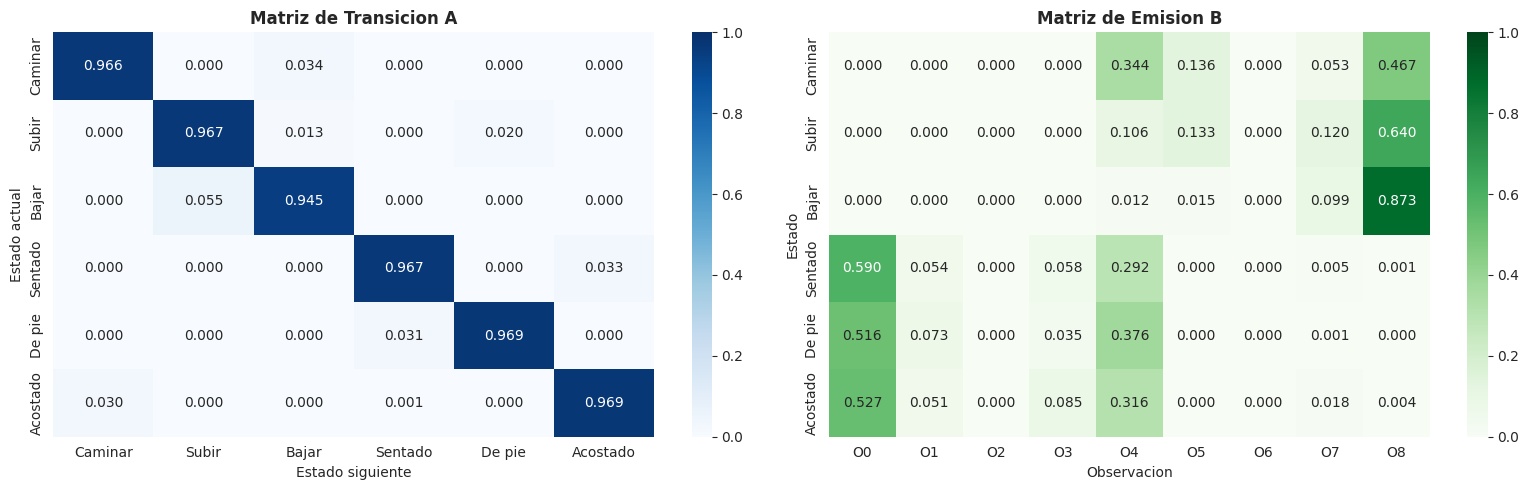

In [5]:
# Visualización de las matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(A, annot=True, fmt='.3f', xticklabels=labels_estados, yticklabels=labels_estados,
            cmap='Blues', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Matriz de Transicion A', fontweight='bold')
axes[0].set_xlabel('Estado siguiente')
axes[0].set_ylabel('Estado actual')

sns.heatmap(B, annot=True, fmt='.3f', xticklabels=[f'O{i}' for i in range(n_obs)],
            yticklabels=labels_estados, cmap='Greens', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz de Emision B', fontweight='bold')
axes[1].set_xlabel('Observacion')
axes[1].set_ylabel('Estado')

plt.tight_layout()
plt.show()

In [6]:
# Construcción del modelo HMM en hmmlearn
# Suavizado de Laplace para evitar log(0)
A_smooth = (A + 1e-6)
A_smooth = A_smooth / A_smooth.sum(axis=1, keepdims=True)
B_smooth = (B + 1e-6)
B_smooth = B_smooth / B_smooth.sum(axis=1, keepdims=True)
pi_smooth = pi.copy()
pi_smooth[pi_smooth == 0] = 1e-6
pi_smooth = pi_smooth / pi_smooth.sum()

modelo = hmm.CategoricalHMM(n_components=6, init_params="")
modelo.startprob_ = pi_smooth
modelo.transmat_ = A_smooth
modelo.emissionprob_ = B_smooth

print("Modelo HMM construido con parámetros manuales.")
print(f"  Estados: {modelo.n_components}")
print(f"  Validación - pi suma: {modelo.startprob_.sum():.4f}")
print(f"  Validación - A filas suman: {modelo.transmat_.sum(axis=1)}")
print(f"  Validación - B filas suman: {modelo.emissionprob_.sum(axis=1)}")

Modelo HMM construido con parámetros manuales.
  Estados: 6
  Validación - pi suma: 1.0000
  Validación - A filas suman: [1. 1. 1. 1. 1. 1.]
  Validación - B filas suman: [1. 1. 1. 1. 1. 1.]


## 2.3 Algoritmo Forward-Backward

### ¿Qué hace Forward-Backward?
Es un algoritmo que calcula la **probabilidad de estar en cada estado en cada instante de tiempo**, dado que conocemos toda la secuencia de observaciones. Calcula:

- **Forward ($\alpha$):** Probabilidad de observar $o_1, o_2, ..., o_t$ y estar en estado $i$ en el tiempo $t$.
- **Backward ($\beta$):** Probabilidad de observar $o_{t+1}, ..., o_T$ dado que estamos en estado $i$ en $t$.
- **Posterior ($\gamma$):** Combina ambos: $\gamma_t(i) = P(q_t = i | O, \lambda)$. Es la probabilidad a posteriori de estar en el estado $i$ en el tiempo $t$ dada **toda** la secuencia observada.

Se selecciona una subsecuencia real de longitud 20 del sujeto 1 para aplicar el algoritmo.

In [7]:
# Seleccionar subsecuencia del sujeto 1 (longitud 20)
seq_length = 20
seq = secuencias_obs[0][:seq_length].reshape(-1, 1)
real = secuencias_states[0][:seq_length]

print(f"Subsecuencia seleccionada (Sujeto 1, primeras {seq_length} observaciones):")
print(f"  Observaciones: {seq.flatten()}")
print(f"  Estados reales: {real}")
print(f"  Actividades reales: {[activity_map[s] for s in real]}")

Subsecuencia seleccionada (Sujeto 1, primeras 20 observaciones):
  Observaciones: [3 0 0 0 0 0 0 0 0 0 0 0 0 0 4 1 0 0 0 0]
  Estados reales: [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
  Actividades reales: ['De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie']


In [8]:
# Aplicar Forward-Backward (score_samples devuelve posteriors gamma)
log_likelihood, posteriors = modelo.score_samples(seq)

print(f"Log-verosimilitud de la secuencia: {log_likelihood:.4f}")
print(f"Posteriors shape: {posteriors.shape} (tiempo x estados)")
print(f"Verificación: cada fila suma 1: {np.allclose(posteriors.sum(axis=1), 1)}")

# Tabla completa de probabilidades a posteriori
df_post = pd.DataFrame(
    posteriors.round(4),
    columns=labels_estados,
    index=[f"t={t}" for t in range(seq_length)]
)
print(f"\nProbabilidades a posteriori gamma(estado, t):")
print(df_post.to_string())

Log-verosimilitud de la secuencia: -17.8083
Posteriors shape: (20, 6) (tiempo x estados)
Verificación: cada fila suma 1: True

Probabilidades a posteriori gamma(estado, t):
      Caminar  Subir  Bajar  Sentado  De pie  Acostado
t=0       0.0    0.0    0.0   0.0000  1.0000    0.0000
t=1       0.0    0.0    0.0   0.0818  0.9182    0.0000
t=2       0.0    0.0    0.0   0.1527  0.8469    0.0004
t=3       0.0    0.0    0.0   0.2141  0.7847    0.0012
t=4       0.0    0.0    0.0   0.2670  0.7305    0.0026
t=5       0.0    0.0    0.0   0.3123  0.6833    0.0044
t=6       0.0    0.0    0.0   0.3510  0.6422    0.0068
t=7       0.0    0.0    0.0   0.3837  0.6065    0.0098
t=8       0.0    0.0    0.0   0.4110  0.5755    0.0135
t=9       0.0    0.0    0.0   0.4334  0.5486    0.0180
t=10      0.0    0.0    0.0   0.4514  0.5253    0.0233
t=11      0.0    0.0    0.0   0.4654  0.5051    0.0295
t=12      0.0    0.0    0.0   0.4755  0.4877    0.0367
t=13      0.0    0.0    0.0   0.4821  0.4728    0.0451
t=

In [9]:
# ════════════════════════════════════════════════════════
# CONSULTA 1: ¿Cuál es el estado más probable en t=0?
# ════════════════════════════════════════════════════════
print("=" * 70)
print("CONSULTA 1: ¿Cuál es el estado más probable en t=0?")
print("=" * 70)
t = 0
probs_t0 = posteriors[t]
estado_mas_probable = np.argmax(probs_t0)
print(f"Probabilidades en t={t}:")
for i in range(n_states):
    marca = " <-- MAS PROBABLE" if i == estado_mas_probable else ""
    print(f"  P({labels_estados[i]} | O) = {probs_t0[i]:.4f}{marca}")
print(f"\nEstado predicho: {activity_map[estado_mas_probable]}")
print(f"Estado real:     {activity_map[real[t]]}")
print(f"¿Coincide?       {'SI' if estado_mas_probable == real[t] else 'NO'}")

# ════════════════════════════════════════════════════════
# CONSULTA 2: ¿Cuál es la probabilidad de estar Sentado en t=15?
# ════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("CONSULTA 2: ¿Cuál es la probabilidad de estar Sentado en t=15?")
print("=" * 70)
t = 15
idx_sentado = 3
prob_sentado = posteriors[t, idx_sentado]
print(f"P(Sentado en t={t}) = {prob_sentado:.4f}")
print(f"Estado real en t={t}: {activity_map[real[t]]}")
print(f"Estado más probable en t={t}: {activity_map[np.argmax(posteriors[t])]} (P={posteriors[t].max():.4f})")
print(f"\nTodas las probabilidades en t={t}:")
for i in range(n_states):
    print(f"  P({labels_estados[i]}) = {posteriors[t, i]:.4f}")

# ════════════════════════════════════════════════════════
# CONSULTA 3: ¿En qué instante es más probable estar Caminando?
# ════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("CONSULTA 3: ¿En qué instante es más probable estar Caminando?")
print("=" * 70)
idx_caminar = 0
probs_caminar = posteriors[:, idx_caminar]
mejor_t = np.argmax(probs_caminar)
print(f"P(Caminar) por instante:")
for t_i in range(seq_length):
    marca = " <-- MAX" if t_i == mejor_t else ""
    print(f"  t={t_i:2d}: P(Caminar) = {probs_caminar[t_i]:.4f}{marca}")
print(f"\nInstante con mayor P(Caminar): t={mejor_t} (P={probs_caminar[mejor_t]:.4f})")

# ════════════════════════════════════════════════════════
# CONSULTA 4: ¿Probabilidad de actividad dinámica vs estática en t=10?
# ════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("CONSULTA 4: P(actividad dinámica) vs P(actividad estática) en t=10")
print("=" * 70)
t = 10
p_dinamica = posteriors[t, 0] + posteriors[t, 1] + posteriors[t, 2]
p_estatica = posteriors[t, 3] + posteriors[t, 4] + posteriors[t, 5]
print(f"Actividades dinámicas (Caminar + Subir + Bajar):")
print(f"  P = {posteriors[t,0]:.4f} + {posteriors[t,1]:.4f} + {posteriors[t,2]:.4f} = {p_dinamica:.4f}")
print(f"Actividades estáticas (Sentado + De pie + Acostado):")
print(f"  P = {posteriors[t,3]:.4f} + {posteriors[t,4]:.4f} + {posteriors[t,5]:.4f} = {p_estatica:.4f}")
print(f"\nEstado real en t={t}: {activity_map[real[t]]}")

CONSULTA 1: ¿Cuál es el estado más probable en t=0?
Probabilidades en t=0:
  P(Caminar | O) = 0.0000
  P(Subir | O) = 0.0000
  P(Bajar | O) = 0.0000
  P(Sentado | O) = 0.0000
  P(De pie | O) = 1.0000 <-- MAS PROBABLE
  P(Acostado | O) = 0.0000

Estado predicho: De pie
Estado real:     De pie
¿Coincide?       SI

CONSULTA 2: ¿Cuál es la probabilidad de estar Sentado en t=15?
P(Sentado en t=15) = 0.4924
Estado real en t=15: De pie
Estado más probable en t=15: Sentado (P=0.4924)

Todas las probabilidades en t=15:
  P(Caminar) = 0.0000
  P(Subir) = 0.0000
  P(Bajar) = 0.0000
  P(Sentado) = 0.4924
  P(De pie) = 0.4436
  P(Acostado) = 0.0639

CONSULTA 3: ¿En qué instante es más probable estar Caminando?
P(Caminar) por instante:
  t= 0: P(Caminar) = 0.0000
  t= 1: P(Caminar) = 0.0000
  t= 2: P(Caminar) = 0.0000
  t= 3: P(Caminar) = 0.0000
  t= 4: P(Caminar) = 0.0000
  t= 5: P(Caminar) = 0.0000
  t= 6: P(Caminar) = 0.0000
  t= 7: P(Caminar) = 0.0000
  t= 8: P(Caminar) = 0.0000
  t= 9: P(Camina

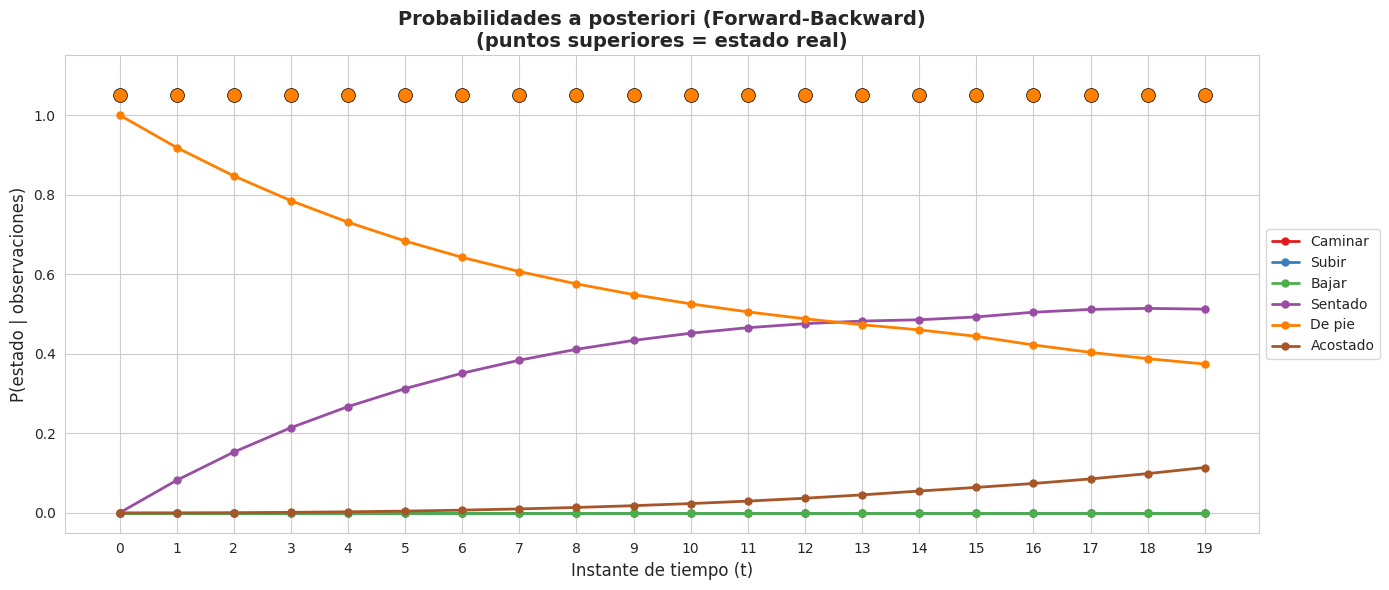

In [10]:
# Visualización de las probabilidades a posteriori
colors_hmm = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

fig, ax = plt.subplots(figsize=(14, 6))
for i in range(n_states):
    ax.plot(range(seq_length), posteriors[:, i], 'o-', label=labels_estados[i],
            color=colors_hmm[i], linewidth=2, markersize=5)

# Marcar estados reales arriba
for t in range(seq_length):
    ax.scatter(t, 1.05, color=colors_hmm[real[t]], s=100, zorder=5,
              edgecolors='black', linewidth=0.5)

ax.set_xlabel('Instante de tiempo (t)', fontsize=12)
ax.set_ylabel('P(estado | observaciones)', fontsize=12)
ax.set_title('Probabilidades a posteriori (Forward-Backward)\n(puntos superiores = estado real)',
             fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xticks(range(seq_length))
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.show()

## 2.4 Algoritmo de Viterbi

### ¿Qué hace Viterbi?
Encuentra la **secuencia de estados más probable** dada toda la secuencia de observaciones. A diferencia de Forward-Backward (que da probabilidades marginales por instante), Viterbi **optimiza la secuencia completa** de forma conjunta.

También calculamos **P(O|modelo)**: la probabilidad total de observar la secuencia bajo nuestro modelo, usando el algoritmo Forward.

In [11]:
# Aplicar Viterbi
log_prob_viterbi, estados_viterbi = modelo.decode(seq, algorithm="viterbi")

print("Secuencia de estados más probable (Viterbi):")
print(f"  Estados:     {estados_viterbi}")
print(f"  Actividades: {[activity_map[s] for s in estados_viterbi]}")
print(f"\n  Log-probabilidad Viterbi: {log_prob_viterbi:.4f}")
print(f"  Probabilidad Viterbi:     {np.exp(log_prob_viterbi):.6e}")

# Comparación detallada Viterbi vs Real
print(f"\n{'t':>3} | {'Real':>12} | {'Viterbi':>12} | {'Coincide':>10}")
print("-" * 45)
aciertos = 0
for t in range(seq_length):
    r = activity_map[real[t]]
    v = activity_map[estados_viterbi[t]]
    ok = "SI" if real[t] == estados_viterbi[t] else "NO"
    if real[t] == estados_viterbi[t]:
        aciertos += 1
    print(f"{t:>3} | {r:>12} | {v:>12} | {ok:>10}")

print(f"\nPrecisión: {aciertos}/{seq_length} = {aciertos/seq_length:.1%}")

Secuencia de estados más probable (Viterbi):
  Estados:     [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
  Actividades: ['De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie', 'De pie']

  Log-probabilidad Viterbi: -18.7917
  Probabilidad Viterbi:     6.900605e-09

  t |         Real |      Viterbi |   Coincide
---------------------------------------------
  0 |       De pie |       De pie |         SI
  1 |       De pie |       De pie |         SI
  2 |       De pie |       De pie |         SI
  3 |       De pie |       De pie |         SI
  4 |       De pie |       De pie |         SI
  5 |       De pie |       De pie |         SI
  6 |       De pie |       De pie |         SI
  7 |       De pie |       De pie |         SI
  8 |       De pie |       De pie |         SI
  9 |       De pie |       De pie |         SI
 10 |       De pie |       De pie |    

In [12]:
# Probabilidad total de la secuencia observada P(O|modelo)
log_prob_seq = modelo.score(seq)

print(f"Probabilidad de la secuencia observada P(O|modelo):")
print(f"  Log P(O|modelo) = {log_prob_seq:.4f}")
print(f"  P(O|modelo) = {np.exp(log_prob_seq):.6e}")

print(f"\nComparación con el camino Viterbi:")
print(f"  Log P(camino Viterbi) = {log_prob_viterbi:.4f}")
print(f"  Ratio = P(Viterbi) / P(total) = {np.exp(log_prob_viterbi - log_prob_seq):.4f}")
print(f"  El camino Viterbi concentra el {np.exp(log_prob_viterbi - log_prob_seq)*100:.2f}% de la probabilidad total.")

Probabilidad de la secuencia observada P(O|modelo):
  Log P(O|modelo) = -17.8083
  P(O|modelo) = 1.844889e-08

Comparación con el camino Viterbi:
  Log P(camino Viterbi) = -18.7917
  Ratio = P(Viterbi) / P(total) = 0.3740
  El camino Viterbi concentra el 37.40% de la probabilidad total.


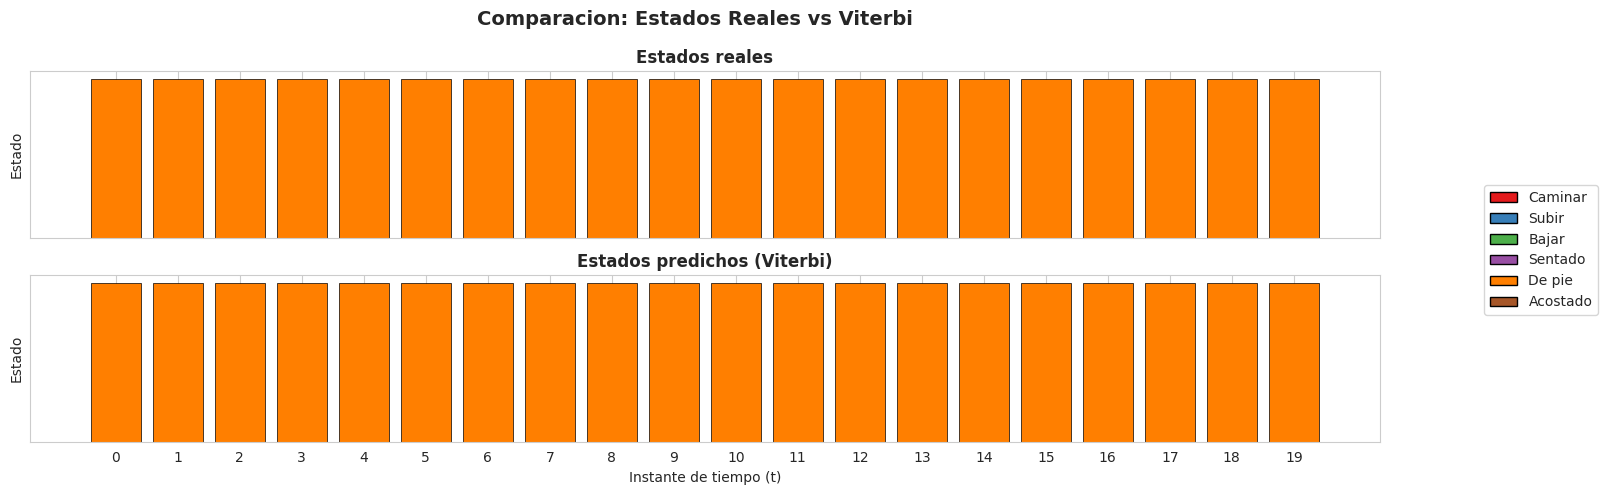

In [13]:
# Visualización comparativa: Viterbi vs Real
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

for t in range(seq_length):
    axes[0].bar(t, 1, color=colors_hmm[real[t]], edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Estado')
axes[0].set_title('Estados reales', fontweight='bold')
axes[0].set_yticks([])

for t in range(seq_length):
    axes[1].bar(t, 1, color=colors_hmm[estados_viterbi[t]], edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Estado')
axes[1].set_title('Estados predichos (Viterbi)', fontweight='bold')
axes[1].set_yticks([])
axes[1].set_xlabel('Instante de tiempo (t)')
axes[1].set_xticks(range(seq_length))

legend_elements = [Patch(facecolor=colors_hmm[i], edgecolor='black',
                         label=labels_estados[i]) for i in range(n_states)]
fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Comparacion: Estados Reales vs Viterbi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 Análisis e interpretación de resultados

### Definición de estados y observaciones
- Se definieron 6 estados correspondientes a las actividades del dataset HAR.
- Se crearon 9 observaciones combinando 2 índices de sensores (aceleración y giroscopio), cada uno discretizado en 3 niveles por terciles.
- La discretización por terciles genera grupos equilibrados y es robusta ante outliers.

### Matriz de transición
- La diagonal de A tiene valores altos (>0.94), indicando que las actividades **persisten en el tiempo**: una persona que camina tiende a seguir caminando.
- Las transiciones entre actividades dinámicas (Caminar, Subir, Bajar) son más frecuentes entre sí.
- Las actividades estáticas (Sentado, De pie, Acostado) también transicionan principalmente entre ellas.
- Esto refleja la naturaleza temporal de las actividades humanas.

### Matriz de emisión
- Las actividades dinámicas generan observaciones con **alta aceleración** (obs 7, 8).
- Las actividades estáticas generan observaciones con **baja aceleración** (obs 0, 3, 4).
- LAYING (Acostado) tiene un patrón similar a Sentado pero con más variabilidad en giroscopio, debido a la orientación del sensor.

### Forward-Backward
- Las probabilidades a posteriori muestran que el modelo distingue bien entre actividades estáticas y dinámicas.
- En los instantes donde la observación es ambigua, la probabilidad se reparte entre estados similares (ej: Sentado vs De pie).
- El algoritmo utiliza **toda la secuencia** para refinar las probabilidades, por lo que incluso en instantes con observaciones poco informativas, el contexto temporal ayuda.

### Viterbi
- El camino de Viterbi tiende a ser **temporalmente coherente** (pocos cambios bruscos) porque optimiza la secuencia completa.
- La precisión del modelo depende de la calidad de la discretización: al reducir 561 features a 2 índices y 9 observaciones, se pierde información discriminativa.
- El ratio P(Viterbi)/P(total) indica cuánta masa de probabilidad concentra el camino óptimo.

### Limitaciones
- La reducción de 561 features a solo 2 índices pierde mucha información.
- El modelo asume independencia condicional de observaciones dado el estado, lo cual puede no ser completamente válido.
- La propiedad de Markov (el futuro solo depende del presente) puede ser limitante para patrones de actividad más complejos.
- El vector pi estimado es muy concentrado (solo en "De pie"), lo que refleja que los datos de entrenamiento siempre comenzaban con esa actividad.

---